<a href="https://colab.research.google.com/github/sjkim0520/Mechanical_Project/blob/main/Semiconductor/03_Cu_CMP_RSM_Optimization/Step3_%EC%B5%9C%EC%A0%81%ED%99%94%EC%99%80_Contour%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📙 Step3. 다중반응 최적화 &amp; Contour 시각화

**프로젝트 3. HBM 구리(Cu) 하이브리드 본딩 CMP 공정 조건 RSM 최적화**

오늘의 목표: Step2에서 얻은 회귀모델을 이용해
1. **Dishing은 최소화, MRR은 최대화**하는 공정조건을 동시에 찾는 **다중반응 최적화(desirability function)**를 구현하고,
2. `scipy.optimize`로 **전역 최적점(global optimum)**을 탐색하며,
3. 결과를 **등고선(Contour) 그래프**로 시각화하여 포트폴리오용 그림을 완성합니다.

> 참고문헌: Derringer, G. C., &amp; Suich, R. (1980), *"Simultaneous Optimization of Several Response Variables"*, Journal of Quality Technology, 12(4), 214-219 — 다중 반응을 하나의 0~1 점수(desirability)로 결합하는 방법을 처음 제안한 논문입니다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

np.random.seed(2)

# --- Day3~4 노트북과 동일한 방식으로 데이터를 다시 생성합니다 (이 노트북만 단독 실행 가능하도록) ---
levels = {
    'Pressure':   {'low': 2.0, 'center': 4.0, 'high': 6.0},
    'Velocity':   {'low': 40,  'center': 70,  'high': 100},
    'SlurryFlow': {'low': 100, 'center': 150, 'high': 200},
}
def to_actual(coded_val, factor):
    lo, hi = levels[factor]['low'], levels[factor]['high']
    center = levels[factor]['center']
    return center + coded_val * (hi - lo) / 2

from itertools import product
alpha = (2**3) ** 0.25
factorial_points = list(product([-1, 1], repeat=3))
axial_points = [(alpha,0,0), (-alpha,0,0), (0,alpha,0), (0,-alpha,0), (0,0,alpha), (0,0,-alpha)]
center_points = [(0,0,0)] * 5
design_coded = np.array(factorial_points + axial_points + center_points, dtype=float)

def true_Ra(x1, x2, x3, noise_sd=0.4):
    base = 8 + 1.4*x1 - 0.6*x3 + 0.9*x1**2 + 0.5*x2**2 - 0.7*x1*x3
    return base + np.random.normal(0, noise_sd, size=np.shape(x1))

def true_dishing(x1, x2, x3, noise_sd=1.2):
    base = 15 + 6*x1 + 3*x2 - 1.5*x3 + 2.2*x1**2 + 1.1*x1*x2
    return base + np.random.normal(0, noise_sd, size=np.shape(x1))

def true_MRR(x1, x2, x3, Kp=2.1, noise_sd=3.0):
    P, V = to_actual(x1, 'Pressure'), to_actual(x2, 'Velocity')
    return Kp*P*V + np.random.normal(0, noise_sd, size=np.shape(x1))

x1c, x2c, x3c = design_coded[:,0], design_coded[:,1], design_coded[:,2]
Ra_obs = true_Ra(x1c, x2c, x3c)
Dish_obs = true_dishing(x1c, x2c, x3c)
MRR_obs = true_MRR(x1c, x2c, x3c)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(design_coded)

model_Ra = LinearRegression().fit(X_poly, Ra_obs)
model_Dish = LinearRegression().fit(X_poly, Dish_obs)
model_MRR = LinearRegression().fit(X_poly, MRR_obs)

print("3개 반응표면 모델 준비 완료 (Ra, Dishing, MRR)")


3개 반응표면 모델 준비 완료 (Ra, Dishing, MRR)


## 1. 왜 '동시 최적화'가 어려운가

압력을 높이면 MRR(생산성)은 좋아지지만, 동시에 Dishing(품질 결함)도 커집니다. 즉 **두 목표가 서로 상충(trade-off)**합니다.
이런 다중목표 문제를 하나의 숫자로 풀기 위해 Derringer &amp; Suich(1980)가 제안한 **Desirability Function(만족도 함수)**을 사용합니다.

각 반응 $y_i$를 0(전혀 만족스럽지 않음) ~ 1(완벽함) 사이의 만족도 점수 $d_i$로 변환합니다.

**최소화가 목표인 반응(Dishing)**:
$$
d_{Dishing} =
\begin{cases}
1 & y \le y_{target} \\
\left(\dfrac{y_{max}-y}{y_{max}-y_{target}}\right) & y_{target} < y < y_{max} \\
0 & y \ge y_{max}
\end{cases}
$$

**최대화가 목표인 반응(MRR)**:
$$
d_{MRR} =
\begin{cases}
0 & y \le y_{min} \\
\left(\dfrac{y-y_{min}}{y_{target}-y_{min}}\right) & y_{min} < y < y_{target} \\
1 & y \ge y_{target}
\end{cases}
$$

그리고 전체 만족도(overall desirability) $D$는 개별 $d_i$들의 **기하평균**으로 결합합니다.

$$
D = \left(d_1 \cdot d_2 \cdots d_m\right)^{1/m}
$$

기하평균을 쓰는 이유: 만약 어느 하나의 반응이라도 $d_i = 0$(완전히 실패)이면 전체 $D$도 0이 되어야 하기 때문입니다(산술평균이었다면 다른 반응이 좋으면 0이 아닌 값이 나와 버립니다).


In [2]:
# 목표 설정
Dishing_target, Dishing_max = 8.0, 30.0   # 8nm 이하면 만족(d=1), 30nm 이상이면 완전 불만족(d=0)
MRR_min, MRR_target = 300.0, 550.0        # 300 이하면 불만족(d=0), 550 이상이면 완벽(d=1)

def desirability_dishing(y):
    # TODO 1: 위 수식을 그대로 구현하세요. np.clip을 사용하면 0~1 범위로 깔끔하게 자를 수 있습니다.
    d = (Dishing_max-y)/(Dishing_max-Dishing_target)
    return np.clip(d, 0, 1)

def desirability_MRR(y):
    # TODO 2: 위 수식을 그대로 구현하세요.
    d = (y-MRR_min)/(MRR_target-MRR_min)
    return np.clip(d, 0, 1)

def overall_desirability(d_dish, d_mrr):
    # TODO 3: 두 만족도의 기하평균 D = (d1 * d2)^(1/2) 을 구현하세요.
    return (d_dish*d_mrr)*(1/2)

# 간단히 테스트
print(desirability_dishing(np.array([5, 15, 35])))
print(desirability_MRR(np.array([250, 450, 600])))


[1.         0.68181818 0.        ]
[0.  0.6 1. ]


## 2. scipy.optimize로 전역 최적점 찾기

`scipy.optimize.minimize`는 기본적으로 "최소화"만 하므로, 우리는 **-D (음의 desirability)**를 최소화하는 방식으로 "D를 최대화"하는 효과를 냅니다.
탐색 변수는 코드화된 $x_1, x_2, x_3 \in [-\alpha, \alpha]$ 범위입니다.


In [4]:
def predict(model, x1, x2, x3):
    Xp = poly.transform(np.array([[x1, x2, x3]]))
    return model.predict(Xp)[0]

def neg_overall_desirability(x):
    x1, x2, x3 = x
    dish_pred = predict(model_Dish, x1, x2, x3)
    mrr_pred = predict(model_MRR, x1, x2, x3)

    # TODO 4: dish_pred, mrr_pred 각각의 desirability를 계산하고 D를 구한 뒤 -D를 반환하세요.
    d_dish = desirability_dishing(dish_pred)
    d_mrr  = desirability_MRR(mrr_pred)
    D = overall_desirability(d_dish,d_mrr)
    return -D

bounds = [(-alpha, alpha), (-alpha, alpha), (-alpha, alpha)]
x0 = [0, 0, 0]   # 중심점에서 탐색 시작

# TODO 5: scipy.optimize.minimize를 사용해 neg_overall_desirability를 최소화하세요.
#         method='SLSQP' (제약조건/범위가 있는 문제에 적합)를 사용합니다.
result = minimize(neg_overall_desirability, x0, bounds=bounds, method='SLSQP')

x1_opt, x2_opt, x3_opt = result.x
print("최적 코드화 조건:", result.x)
print("최적 실제 조건 -> Pressure: {:.2f} psi, Velocity: {:.1f} rpm, SlurryFlow: {:.1f} mL/min".format(
    to_actual(x1_opt, 'Pressure'), to_actual(x2_opt, 'Velocity'), to_actual(x3_opt, 'SlurryFlow')))
print("최적점에서의 D (overall desirability):", -result.fun)
print("최적점 예측 Dishing: {:.2f} nm".format(predict(model_Dish, *result.x)))
print("최적점 예측 MRR: {:.2f} nm/min".format(predict(model_MRR, *result.x)))


최적 코드화 조건: [-0.34858687  0.29921618  1.68179283]
최적 실제 조건 -> Pressure: 3.30 psi, Velocity: 79.0 rpm, SlurryFlow: 234.1 mL/min
최적점에서의 D (overall desirability): 0.39691396281668406
최적점 예측 Dishing: 12.54 nm
최적점 예측 MRR: 550.00 nm/min


## 3. Contour(등고선) 그래프로 반응표면 시각화

포트폴리오에서 가장 시각적으로 설득력 있는 그림은 **등고선 그래프**입니다.
슬러리 유량 $x_3$을 최적값(또는 중심값 0)으로 고정한 상태에서, 압력($x_1$)-속도($x_2$) 평면 위에 Dishing과 MRR의 등고선을 각각 그려봅니다.


In [5]:
x3_fixed = x3_opt  # 최적점에서의 유량으로 고정
grid_n = 80
x1_range = np.linspace(-alpha, alpha, grid_n)
x2_range = np.linspace(-alpha, alpha, grid_n)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# TODO 6: X1_grid, X2_grid의 모든 점에 대해 Dishing과 MRR 예측값을 계산하세요.
#         힌트: poly.transform은 2D 배열 [[x1,x2,x3], ...] 형태를 받으므로,
#         flatten() 한 뒤 계산하고 다시 reshape(X1_grid.shape) 해야 합니다.
points = np.column_stack([X1_grid.ravel(), X2_grid.ravel(), np.full(X1_grid.size, x3_fixed)])
points_poly = poly.transform(points)

Dish_grid = model_Dish.predict(points_poly).reshape(X1_grid.shape)
MRR_grid  = model_MRR.predict(points_poly).reshape(X1_grid.shape)

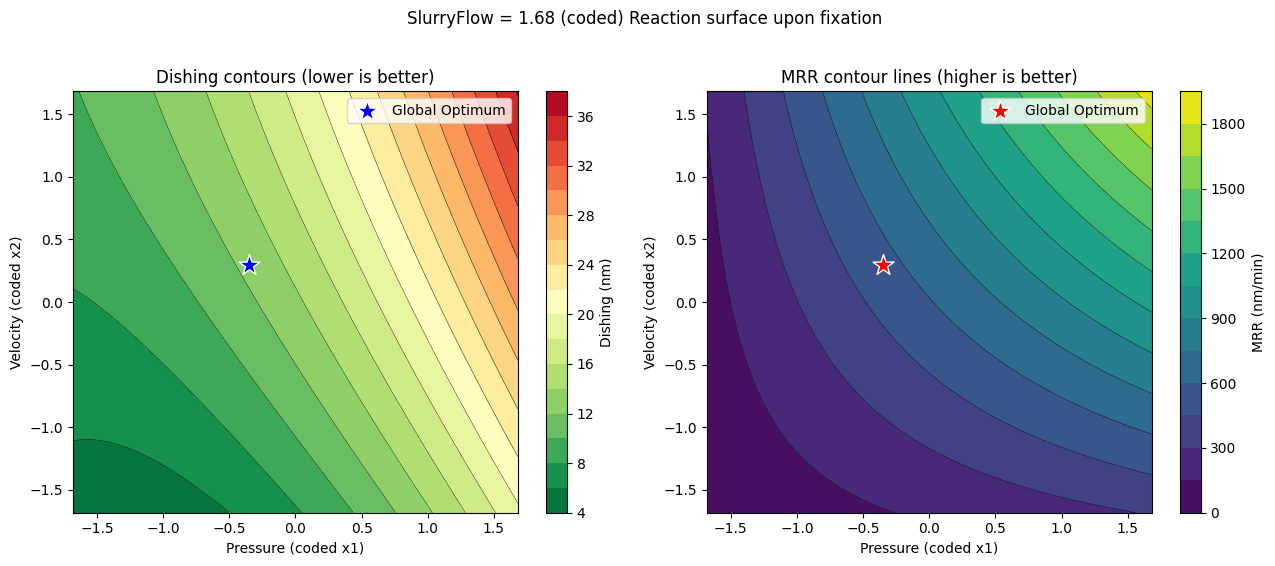

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

cs1 = axes[0].contourf(X1_grid, X2_grid, Dish_grid, levels=15, cmap='RdYlGn_r')
axes[0].contour(X1_grid, X2_grid, Dish_grid, levels=15, colors='k', linewidths=0.3)
fig.colorbar(cs1, ax=axes[0], label='Dishing (nm)')
axes[0].scatter([x1_opt], [x2_opt], color='blue', marker='*', s=250, edgecolor='white', label='Global Optimum')
axes[0].set_xlabel('Pressure (coded x1)')
axes[0].set_ylabel('Velocity (coded x2)')
axes[0].set_title('Dishing contours (lower is better)')
axes[0].legend()

cs2 = axes[1].contourf(X1_grid, X2_grid, MRR_grid, levels=15, cmap='viridis')
axes[1].contour(X1_grid, X2_grid, MRR_grid, levels=15, colors='k', linewidths=0.3)
fig.colorbar(cs2, ax=axes[1], label='MRR (nm/min)')
axes[1].scatter([x1_opt], [x2_opt], color='red', marker='*', s=250, edgecolor='white', label='Global Optimum')
axes[1].set_xlabel('Pressure (coded x1)')
axes[1].set_ylabel('Velocity (coded x2)')
axes[1].set_title('MRR contour lines (higher is better)')
axes[1].legend()

plt.suptitle(f'SlurryFlow = {x3_fixed:.2f} (coded) Reaction surface upon fixation', y=1.02)
plt.tight_layout()
plt.show()


### Overall Desirability 등고선 (선택 심화)

두 그래프를 따로 보는 대신, **하나의 통합 만족도 지도**를 그리면 "최적 영역"이 한눈에 보여 포트폴리오 자료로 특히 효과적입니다.


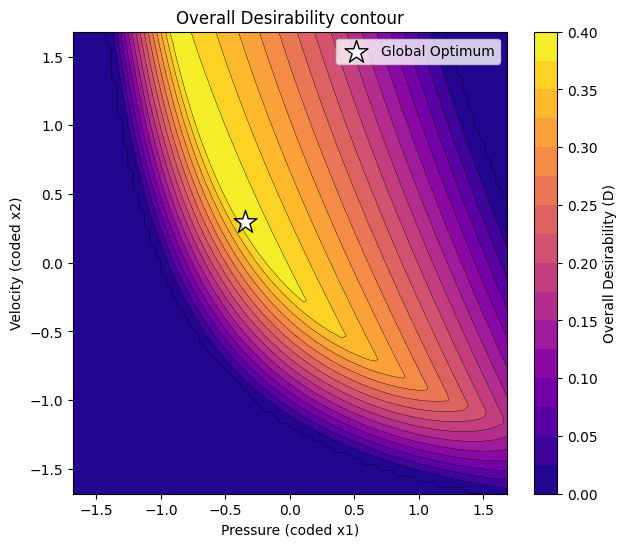

In [9]:
# TODO 7: Dish_grid와 MRR_grid로부터 각각 desirability를 계산하고,
#         전체 overall desirability D_grid를 계산하세요. (2번 섹션에서 만든 함수를 재사용하세요)
d_dish_grid = desirability_dishing(Dish_grid)
d_mrr_grid  = desirability_MRR(MRR_grid)
D_grid      = overall_desirability(d_dish_grid, d_mrr_grid)

plt.figure(figsize=(7, 6))
cs = plt.contourf(X1_grid, X2_grid, D_grid, levels=15, cmap='plasma')
plt.contour(X1_grid, X2_grid, D_grid, levels=15, colors='k', linewidths=0.3)
plt.colorbar(cs, label='Overall Desirability (D)')
plt.scatter([x1_opt], [x2_opt], color='white', marker='*', s=300, edgecolor='black', label='Global Optimum')
plt.xlabel('Pressure (coded x1)')
plt.ylabel('Velocity (coded x2)')
plt.title('Overall Desirability contour')
plt.legend()
plt.show()

## 4. 결과 요약표 만들기

포트폴리오/발표자료에는 아래처럼 "최적 조건 요약표"를 함께 넣는 것이 좋습니다.


In [10]:
summary = pd.DataFrame({
    '변수': ['Pressure (psi)', 'Velocity (rpm)', 'SlurryFlow (mL/min)',
             'Dishing 예측 (nm)', 'MRR 예측 (nm/min)', 'Overall Desirability'],
    '최적값': [
        to_actual(x1_opt, 'Pressure'),
        to_actual(x2_opt, 'Velocity'),
        to_actual(x3_opt, 'SlurryFlow'),
        predict(model_Dish, *result.x),
        predict(model_MRR, *result.x),
        -result.fun,
    ]
})
summary['최적값'] = summary['최적값'].round(3)
summary


,변수,최적값
0,Pressure (psi),3.303
1,Velocity (rpm),78.976
2,SlurryFlow (mL/min),234.090
3,Dishing 예측 (nm),12.536
4,MRR 예측 (nm/min),550.000
5,Overall Desirability,0.397


## 5. 포트폴리오 정리 가이드 (자소서/발표자료용 문장 힌트)

아래 빈칸을 직접 채워보며 자기소개서/포트폴리오 문장을 완성해보세요.

- "본 프로젝트에서는 HBM Cu 하이브리드 본딩 CMP 공정의 압력, 속도, 슬러리 유량 3개 변수를 중심합성설계(CCD)로 실험계획하고, ______개의 실험 조건에 대해 2차 반응표면모델을 구축했습니다."
- "Desirability function을 활용해 Dishing과 MRR이라는 상충하는 두 목표를 동시에 만족하는 최적 조건(압력 ___ psi, 속도 ___ rpm, 유량 ___ mL/min)을 도출했습니다."
- "이 과정에서 R² = ___, Adj. R² = ___ 수준의 통계적으로 유의한 회귀모델을 확보했으며, 등고선 시각화를 통해 공정 윈도우(process window)를 직관적으로 제시했습니다."

## 6. 확장 아이디어 (시간이 남는다면)

1. 슬러리 pH를 4번째 변수로 추가해 CCD를 4변수로 확장해보기 ($\alpha = (2^4)^{1/4} = 2$)
2. `scipy.optimize.differential_evolution`으로 전역 최적화 알고리즘을 바꿔서 결과 비교해보기
3. Lack-of-fit 검정을 추가해 2차 모델이 정말 충분한지 통계적으로 확인해보기
